<a href="https://colab.research.google.com/github/sudhanwa755/Transfer-Learning-with-a-pre-trained-model/blob/main/Transfer_Learning_with_a_pre_trained_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

# 1. Load a smaller subset of the dataset for faster training
# Using 10% of the data for training and 5% for testing
(train_ds, test_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:10%]', 'train[95%:]'],
    as_supervised=True,
    with_info=True
)

# 2. Preprocessing
IMG_SIZE = 150

def preprocess_image(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Increased batch size to 64 for faster processing
BATCH_SIZE = 64
train_batches = train_ds.map(preprocess_image).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_batches = test_ds.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
# 3. Build the CNN Model using Transfer Learning (MobileNetV2)
# This is much faster and more accurate for few epochs

base_model = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False  # Freeze the pre-trained weights

model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/tmp/ipykernel_9499/3683668825.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# 4. Train the Model
# Reduced steps per epoch to finish quickly
EPOCHS = 10
history = model.fit(
    train_batches,
    epochs=EPOCHS,
    validation_data=test_batches,
    steps_per_epoch=20 # Train on a small number of batches for instant results
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.9531 - loss: 0.1189 - val_accuracy: 0.9604 - val_loss: 0.0994
Epoch 2/10
17/20 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9532 - loss: 0.1109

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.9560 - loss: 0.1166 - val_accuracy: 0.9751 - val_loss: 0.0717
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.9688 - loss: 0.0802 - val_accuracy: 0.9725 - val_loss: 0.0739
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9694 - loss: 0.0900 - val_accuracy: 0.9682 - val_loss: 0.0837
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.9742 - loss: 0.0681 - val_accuracy: 0.9708 - val_loss: 0.0697
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9742 - loss: 0.0574 - val_accuracy: 0.9699 - val_loss: 0.0683
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.9891 - loss: 0.0384 - val_accuracy: 0.9690 - val_loss: 0.0700
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9876 - loss: 0.0465 - val_accuracy: 0.9699 - val_loss: 0.0682
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9914 - loss: 0.0322 - val_accuracy: 0.9673 - val_loss: 0.0688
Ep

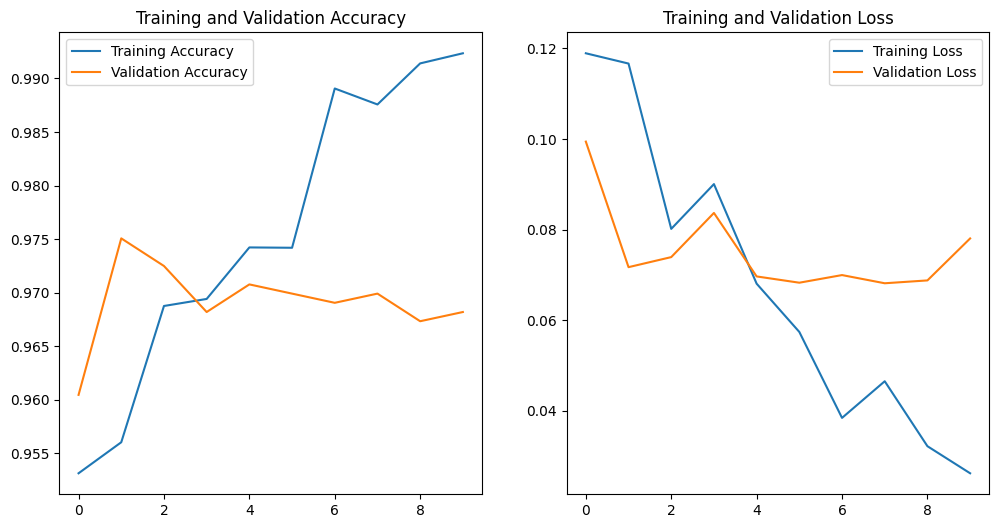

In [ ]:
# 5. Plot Accuracy and Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 891ms/step


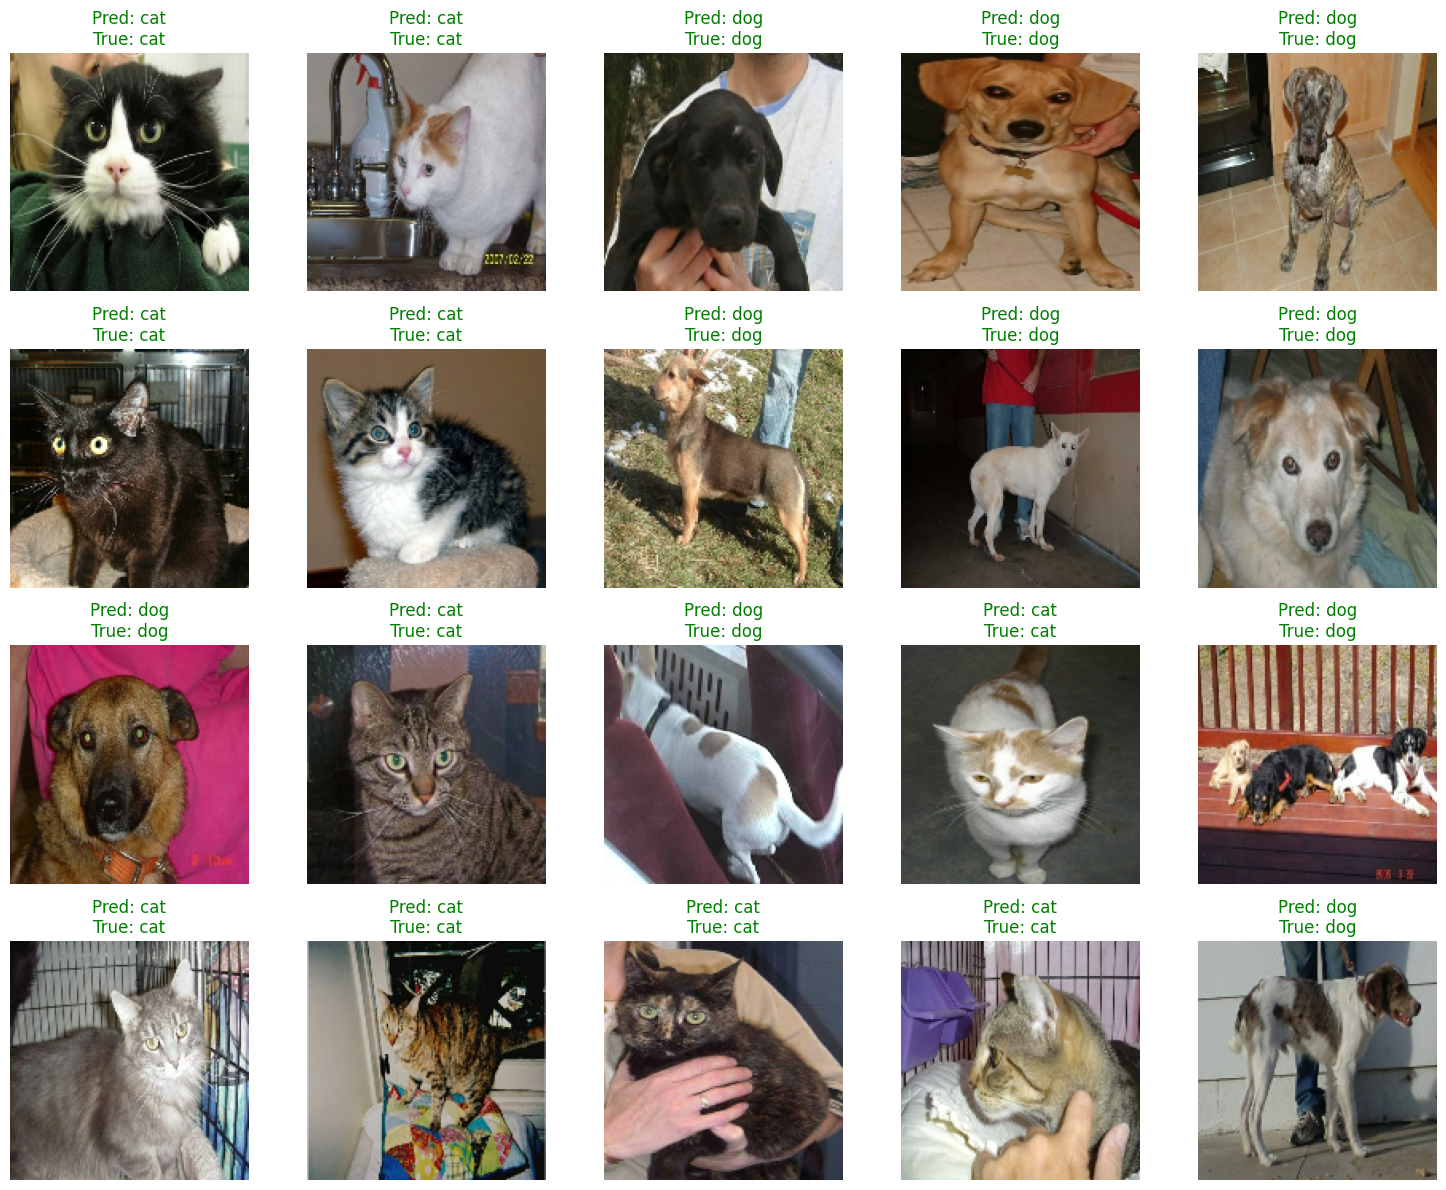

In [ ]:
# 6. Show 20 Prediction Images
class_names = ['cat', 'dog']

plt.figure(figsize=(15, 12))
for images, labels in test_batches.take(1):
    predictions = model.predict(images)
    for i in range(20):
        plt.subplot(4, 5, i + 1)
        plt.imshow(images[i])
        # Sigmoid output > 0.5 is Dog (1), <= 0.5 is Cat (0)
        pred_label = 1 if predictions[i] > 0.5 else 0
        true_label = labels[i].numpy()

        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}", color=color)
        plt.axis('off')
plt.tight_layout()
plt.show()